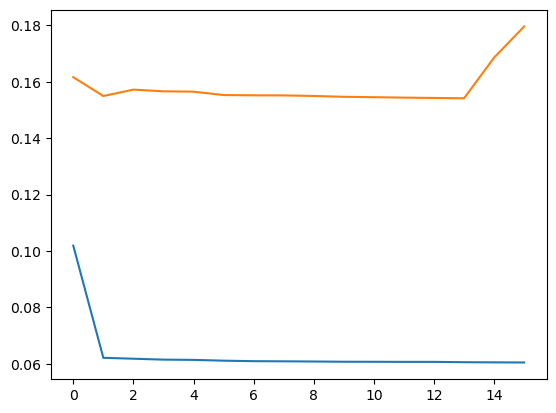

In [3]:
""" 
HW 1 
AERSP 597 Machine Learning
"""
import numpy as np
import matplotlib.pyplot as plt


def phiVector(x,m):
    phi = []
    
    for i in range(len(x)):
        for j in range(m-1):
            phi.append(x[i]**(j+1))
    phi.append(1)
    return phi


def polynomialFunc(x,weights):
    y = 0
    for i in range(len(weights)):
        y += weights[i]*x**i
    return y

# Load data
test = np.loadtxt('flight_data_test.csv',delimiter=',')
train = np.loadtxt('flight_data_train.csv',delimiter=',')


# Normalize data
minTrain = np.min(train,axis = 0)
maxTrain = np.max(train,axis = 0)
train = (train - minTrain)/(maxTrain - minTrain)


minTest = np.min(test,axis = 0)
maxTest = np.max(test,axis = 0)
test = (test - minTest)/(maxTest - minTest)


trainingError = []
testingError = []

maxM = 16

for m in range(maxM):
    m = m + 1
    # Build matrix Phi
    PhiTrain = []
    for row in train:
        PhiTrain.append(phiVector(row[:-1],m))
    
    # Extract the outputs from the data
    tTrain = train[:,-1]
    tTest = test[:,-1]
    
    # Calculate weights
    pseudo = np.linalg.pinv(PhiTrain)
    weights = np.matmul(pseudo,tTrain)
    
    # Test accuracy   
    PhiTest = []
    for row in test:
        PhiTest.append(phiVector(row[:-1],m))
        
    yTrain = np.matmul(PhiTrain,weights)
    yTest = np.matmul(PhiTest,weights) 


    # Calculate training and test error
    trainingError.append( np.sqrt(np.square(yTrain-tTrain).mean() ) )
    testingError.append(  np.sqrt(np.square(yTest -tTest).mean() ) )
    
# Plot RMS vs m
plt.plot(range(m),trainingError)
plt.plot(range(m),testingError)
plt.show()

    



